# Notebook 03: K-means clustering in NMF embedding space

This notebook clusters participants based on their NMF component loadings (the `W` matrix) using K-means, with silhouette scoring to select the number of clusters.

**Inputs (from Notebook 02):**
- `outputs/nmf_W.csv` — participants × components embedding

**Outputs:**
- `outputs/cluster_diagnostics.csv` — silhouette scores across k
- `outputs/cluster_assignments.csv` — one row per participant with cluster label

## Approach

We run K-means for k = 2 to 8 and select the k with the highest mean silhouette score. Because K-means is stochastic, each k is averaged over 20 random seeds to get a reliable estimate. We also check whether clusters exist at all using the Hopkins statistic — if the data is essentially uniform, any clustering will be imposing artificial labels on continuous structure.

## Setup

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(".").resolve().parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"

K_RANGE = range(2, 9)
N_SEEDS = 20
RANDOM_SEED_BASE = 42

## Load NMF embedding

In [12]:
W = pd.read_csv(OUTPUT_DIR / "nmf_W.csv", index_col="participant_id")
print(f"W shape: {W.shape}")
print(f"Components: {list(W.columns)}")
print()
print(W.describe().round(3))

W shape: (86, 5)
Components: ['comp_1', 'comp_2', 'comp_3', 'comp_4', 'comp_5']

       comp_1  comp_2  comp_3  comp_4  comp_5
count  86.000  86.000  86.000  86.000  86.000
mean    0.386   0.389   0.249   0.319   0.239
std     0.330   0.286   0.223   0.287   0.250
min     0.000   0.000   0.000   0.000   0.000
25%     0.160   0.188   0.065   0.098   0.035
50%     0.342   0.336   0.202   0.243   0.157
75%     0.550   0.521   0.365   0.468   0.355
max     1.773   1.110   0.885   1.162   0.984


## Visualize the embedding

Project the 5-dimensional W to 2D via PCA. If clusters exist they'll often (not always) be visible here.

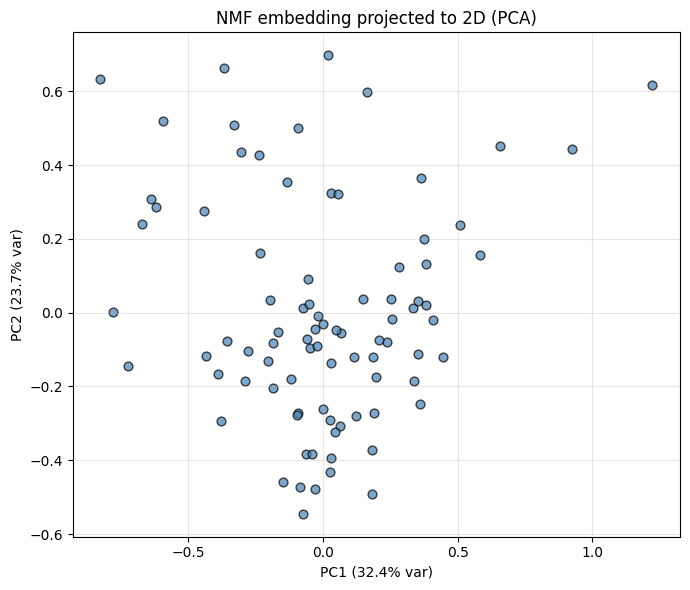


PC1 + PC2 together explain 56.1% of variance in W


In [13]:
pca = PCA(n_components=2)
W_2d = pca.fit_transform(W.values)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(W_2d[:, 0], W_2d[:, 1], s=40, alpha=0.7, color="steelblue", edgecolor="black")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("NMF embedding projected to 2D (PCA)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "embedding_pca_unlabeled.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPC1 + PC2 together explain {sum(pca.explained_variance_ratio_)*100:.1f}% of variance in W")

## Hopkins statistic: does cluster structure exist?

Before clustering, check whether the data has natural grouping or is approximately uniform:

- H ~ 0.5: data is uniformly distributed (no clusters)
- H > 0.75: strong clustering tendency
- H closer to 1.0: very strongly clustered

If H is around 0.5, K-means will still produce nominal labels, but they will not reflect real structure — they will just partition a continuous cloud.

In [14]:
def hopkins_statistic(X, sample_frac=0.1, random_state=42):
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    n_sample = max(2, int(sample_frac * n))

    sample_idx = rng.choice(n, n_sample, replace=False)
    X_sample = X[sample_idx]

    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    X_uniform = rng.uniform(mins, maxs, size=(n_sample, d))

    remaining = np.setdiff1d(np.arange(n), sample_idx)
    nbrs = NearestNeighbors(n_neighbors=1).fit(X[remaining])

    u_dist, _ = nbrs.kneighbors(X_uniform)
    w_dist, _ = nbrs.kneighbors(X_sample)

    u_sum = u_dist.sum()
    w_sum = w_dist.sum()
    return u_sum / (u_sum + w_sum)

hopkins_scores = [hopkins_statistic(W.values, random_state=s) for s in range(20)]
h_mean, h_std = np.mean(hopkins_scores), np.std(hopkins_scores)
print(f"Hopkins statistic: {h_mean:.3f} +/- {h_std:.3f} (averaged over 20 random samples)")

if h_mean < 0.55:
    print("\n[WARN] Data appears nearly uniform - clustering may not reveal meaningful groups.")
    print("       Consider treating the embedding as continuous rather than clustered.")
elif h_mean < 0.75:
    print("\n[WARN] Weak clustering tendency. Clusters may exist but be poorly separated.")
else:
    print("\n[OK] Strong clustering tendency. Proceeding with K-means.")

Hopkins statistic: 0.682 +/- 0.025 (averaged over 20 random samples)

[WARN] Weak clustering tendency. Clusters may exist but be poorly separated.


## K-means across a range of k

Silhouette score ranges from -1 to 1:
- > 0.5: strong cluster separation
- 0.25 - 0.5: moderate
- < 0.25: weak (clusters poorly separated)

In [15]:
results = []
for k in K_RANGE:
    sil_scores = []
    for seed in range(N_SEEDS):
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED_BASE + seed)
        labels = km.fit_predict(W.values)
        sil_scores.append(silhouette_score(W.values, labels))
    results.append({
        "k": k,
        "silhouette_mean": np.mean(sil_scores),
        "silhouette_std": np.std(sil_scores),
        "silhouette_min": np.min(sil_scores),
        "silhouette_max": np.max(sil_scores),
    })

diag_df = pd.DataFrame(results)
diag_df.to_csv(OUTPUT_DIR / "cluster_diagnostics.csv", index=False)
print("K-means silhouette scores across k:")
print(diag_df.round(4).to_string(index=False))

K-means silhouette scores across k:
 k  silhouette_mean  silhouette_std  silhouette_min  silhouette_max
 2           0.2633          0.0119          0.2380          0.3008
 3           0.2223          0.0067          0.2109          0.2273
 4           0.2320          0.0093          0.2122          0.2455
 5           0.1997          0.0242          0.1714          0.2443
 6           0.1959          0.0112          0.1787          0.2264
 7           0.2034          0.0061          0.1921          0.2151
 8           0.2188          0.0065          0.2058          0.2282


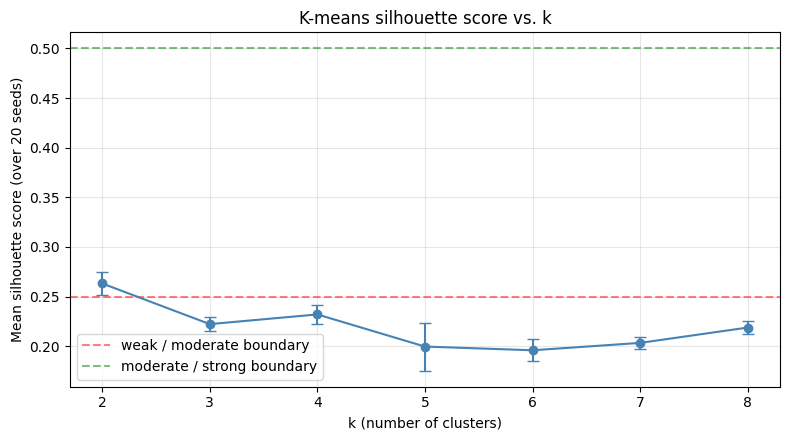

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.errorbar(diag_df["k"], diag_df["silhouette_mean"],
            yerr=diag_df["silhouette_std"], marker="o", capsize=4, color="steelblue")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Mean silhouette score (over 20 seeds)")
ax.set_title("K-means silhouette score vs. k")
ax.set_xticks(list(K_RANGE))
ax.grid(alpha=0.3)
ax.axhline(0.25, color="red", linestyle="--", alpha=0.5, label="weak / moderate boundary")
ax.axhline(0.50, color="green", linestyle="--", alpha=0.5, label="moderate / strong boundary")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "kmeans_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

## Choose k

By default we pick k with the highest mean silhouette. You can override after reviewing the plot.

In [17]:
# >>> EDIT IF DESIRED <<<
CHOSEN_K = int(diag_df.loc[diag_df["silhouette_mean"].idxmax(), "k"])
RATIONALE = f"Selected k = {CHOSEN_K} by maximum mean silhouette score across k = 2-8."

print(f"Chosen k: {CHOSEN_K}")
print(f"Silhouette at chosen k: {diag_df.loc[diag_df['k']==CHOSEN_K, 'silhouette_mean'].values[0]:.4f}")
print(f"Rationale: {RATIONALE}")

Chosen k: 2
Silhouette at chosen k: 0.2633
Rationale: Selected k = 2 by maximum mean silhouette score across k = 2-8.


## Fit final K-means and assign clusters

In [18]:
km = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_SEED_BASE)
final_labels = km.fit_predict(W.values)

cluster_assignments = pd.DataFrame({
    "participant_id": W.index,
    "cluster": final_labels,
})
cluster_assignments.to_csv(OUTPUT_DIR / "cluster_assignments.csv", index=False)

print(f"Final clustering: K-means with k = {CHOSEN_K}")
print("\nCluster sizes:")
print(cluster_assignments["cluster"].value_counts().sort_index().to_string())
print(f"\n[OK] Saved cluster_assignments.csv")

Final clustering: K-means with k = 2

Cluster sizes:
cluster
0    62
1    24

[OK] Saved cluster_assignments.csv


## Visualize clusters in the PCA projection

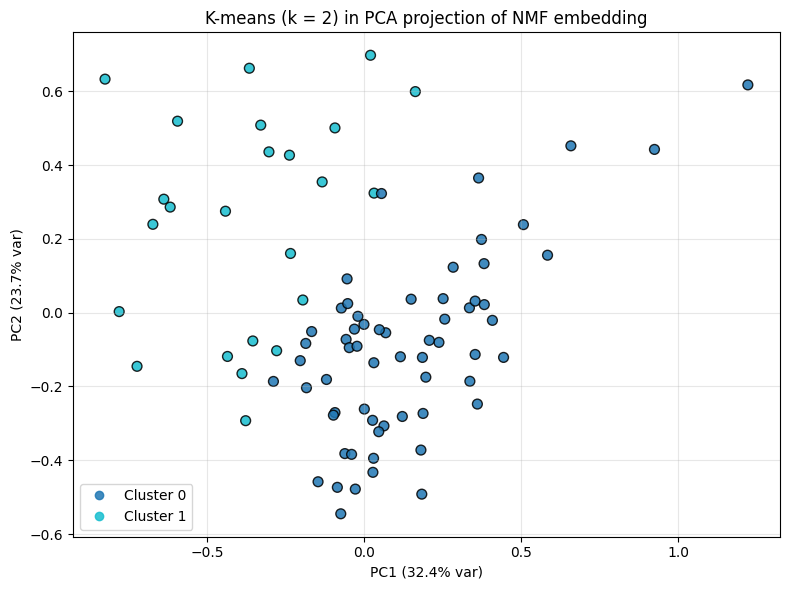

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
scatter = ax.scatter(W_2d[:, 0], W_2d[:, 1], c=final_labels, cmap="tab10",
                     s=50, alpha=0.85, edgecolor="black")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title(f"K-means (k = {CHOSEN_K}) in PCA projection of NMF embedding")
ax.grid(alpha=0.3)

handles, _ = scatter.legend_elements()
labels_text = [f"Cluster {i}" for i in range(CHOSEN_K)]
ax.legend(handles, labels_text, loc="best")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

## Characterize the clusters

For each cluster, what does the average component profile look like? This tells us what differentiates the groups in terms of the five NMF components.

Mean component loading per cluster:
         comp_1  comp_2  comp_3  comp_4  comp_5
cluster                                        
0         0.427   0.317   0.201   0.190   0.169
1         0.280   0.575   0.372   0.653   0.421


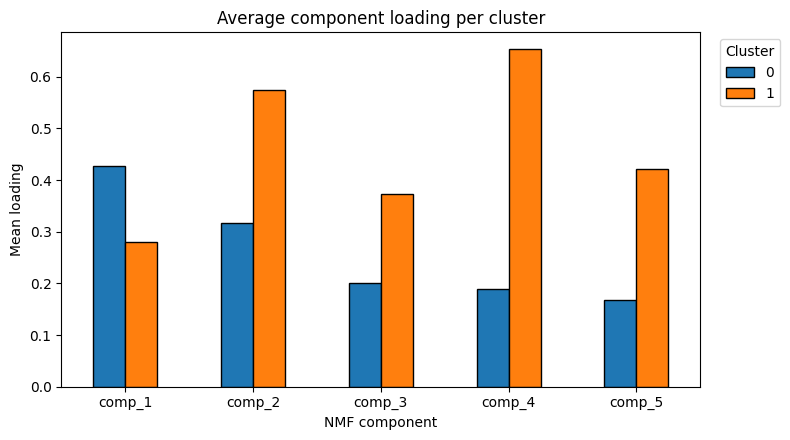

In [20]:
W_with_cluster = W.copy()
W_with_cluster["cluster"] = final_labels

cluster_profiles = W_with_cluster.groupby("cluster").mean()
print("Mean component loading per cluster:")
print(cluster_profiles.round(3))

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
cluster_profiles.T.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("Average component loading per cluster")
ax.set_xlabel("NMF component")
ax.set_ylabel("Mean loading")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()